# **Start**

In [6]:
!pip install pandas
!pip install numpy
!pip install tensorflow
!pip install matplotlib
!pip install seaborn
!pip install scipy
!pip install scikit-learn
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install gpboost
!pip install ngboost
!pip install bayesian-optimization
!pip install optuna
!pip install hyperopt
!pip install keras
!pip install keras-tuner

In [8]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,make_scorer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from gpboost import GPBoostRegressor
from ngboost import NGBRegressor
from bayes_opt import BayesianOptimization
import optuna
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
import tensorflow as tf
from tensorflow import keras
from keras_tuner import Hyperband
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [9]:
train_data_path = r"C:\Users\dell\Desktop\datascience\projects\train1.csv"
test_data_path = r"C:\Users\dell\Desktop\datascience\projects\test1.csv"

In [10]:
train_data = pd.read_csv(train_data_path)
test_data = pd.read_csv(test_data_path)
print("Training data loaded successfully.")
print("Test data loaded successfully.")

Training data loaded successfully.
Test data loaded successfully.


In [16]:
print("\nShape of training data:", train_data.shape)
print("First 10 rows of training data:\n", train_data.head(5))
print("\nShape of test data:", test_data.shape)
print("First 10 rows of test data:\n", test_data.head(5))


Shape of training data: (47, 15)
First 10 rows of training data:
      pH   TDS    EC    TH   ca    mg  CO3  HCO3   NA    K  CHLORIDE  SULPHATE  \
0  7.90   552   865   452  272   180  0.2   4.5  260   44       375       681   
1  7.52  1985  2256  1054  529   525  0.0  15.0  272   47       728       324   
2  7.65  1865  2032   636  371   265  0.0   9.0  373   25       713       503   
3  7.25  4855  7856  2050  795  1255  0.0  12.5  335  106        81       676   
4  7.96  2855  3696   865  310   555  0.3   4.6  184  106       698       324   

   NITRATE  FLUORIDE  Pre monsoon EWQI   
0       60      0.40              70.52  
1       10      0.65             138.78  
2       54      0.85             113.07  
3       17      0.69             266.32  
4       25      1.20             158.05  

Shape of test data: (47, 15)
First 10 rows of test data:
      pH   TDS    EC    TH     ca      mg  CO3  HCO3   NA    K  CHLORIDE  \
0  8.38   625   975   320  120.0   200.0  0.0   5.8  280   3

In [18]:
X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]
X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]
x_test= X_test
print("\nShape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (47, 14)
Shape of y_train: (47,)
Shape of X_test: (47, 14)
Shape of y_test: (47,)


In [20]:
# Apply z-score normalization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Print the first five rows of the normalized data
print("\nFirst five rows of normalized X_train:")
print(X_train[:5])

print("\nFirst five rows of normalized X_test:")
print(X_test[:5])


First five rows of normalized X_train:
[[ 0.3797749  -1.15230942 -0.94309903 -0.47923131 -0.09229732 -0.56852482
  -0.03922784 -1.18768739 -0.02713192 -0.87884263 -0.2770724   1.15873613
   1.41276153 -1.25316406]
 [-0.78765707 -0.2953837  -0.52059702  0.45803078  1.31357822  0.10564733
  -0.50015494  1.61405127  0.07159325 -0.77136925  1.29937074 -0.45273785
  -1.61366471 -0.53733141]
 [-0.38827245 -0.36714301 -0.58863473 -0.19275917  0.44926563 -0.40242444
  -0.50015494  0.01305775  0.90253007 -1.55950739  1.23238307  0.35525611
   1.04959038  0.03533472]
 [-1.61714822  1.42085972  1.18034563  2.00871688  2.76868675  1.53215652
  -0.50015494  0.94697063  0.58990037  1.34227396 -1.59003071  1.13616647
  -1.18996504 -0.42279818]
 [ 0.56410627  0.22487128 -0.08321177  0.16377408  0.11557533  0.16427099
   0.19123571 -1.16100417 -0.6523913   1.34227396  1.1653954  -0.45273785
  -0.70573684  1.03750043]]

First five rows of normalized X_test:
[[ 1.85442582 -1.10865585 -0.90968766 -0.6847

In [22]:
# Define the model classes
model_classes = {
    'Linear Regression': LinearRegression,
    'Decision Tree': DecisionTreeRegressor,
    'Random Forest': RandomForestRegressor,
    'Gradient Boosting': GradientBoostingRegressor,
    'XGBoost': XGBRegressor,
    'LightGBM': LGBMRegressor,
    'GPBoost': GPBoostRegressor,
    'CatBoost': CatBoostRegressor,
    'SVM': SVR,
    'NGBoost': NGBRegressor
}

In [24]:
import os
def predict_and_save_results(results_dict, X_train, y_train, X_test, output_file_path):
    # Check if the output file exists
    if os.path.exists(output_file_path):
        # Read existing predictions DataFrame
        predictions_df = pd.read_csv(output_file_path)
    else:
        # Create a new DataFrame with the same number of rows as X_test
        predictions_df = pd.DataFrame(index=range(X_test.shape[0]))

    for model_name, model_info in results_dict.items():
        best_params = model_info['best_params']
        model_class = model_classes.get(model_name)

        if model_class is None:
            print(f"Model {model_name} is not supported or not available.")
            continue

        # Special handling for CatBoost to suppress verbose output
        if model_name == 'CatBoost':
            model = model_class(**best_params, verbose=0)
        else:
            model = model_class(**best_params)

        # Fit the model
        model.fit(X_train, y_train)

        # Make predictions
        predictions = model.predict(X_test)

        # Add predictions to DataFrame
        predictions_df[f'Sd_{model_name}'] = np.round(predictions, 2)

    # Save predictions to a CSV file at the specified location
    predictions_df.to_csv(output_file_path, index=False)
    print("Predictions have been added to the CSV file.")

In [26]:
# Function for plotting
def plot_best_scores(best_scores_ran):
    # Extract model names and their corresponding best test MSE, RMSE, and correlation coefficient scores
    model_names = list(best_scores_ran.keys())
    test_mse_scores = [best_scores_ran[model]['test_mse'] for model in model_names]
    test_rmse_scores = [best_scores_ran[model]['test_rmse'] for model in model_names]
    corr_coef_scores = [best_scores_ran[model]['test_corr_coef'] for model in model_names]

    # Plot 1: Bar chart for Test MSE
    plt.figure(figsize=(12, 6))
    bars = plt.bar(model_names, test_mse_scores, color='skyblue')

    # Highlight the best model
    best_model_index = np.argmin(test_mse_scores)
    bars[best_model_index].set_color('orange')

    # Annotate the bars with the test MSE scores
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.05,
                 f'{test_mse_scores[i]:.5f}', ha='center', va='bottom', color='black')

    # Add labels and title for the bar chart
    plt.xlabel('Model')
    plt.ylabel('Test MSE')
    plt.title('Best Test MSE')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Plot 2: Point-line graph for RMSE and Correlation Coefficient
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Plot RMSE scores
    ax1.set_xlabel('Model')
    ax1.set_ylabel('Test RMSE', color='tab:blue')
    ax1.plot(model_names, test_rmse_scores, marker='o', color='tab:blue', label='Test RMSE')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Create a second y-axis to plot the correlation coefficient
    ax2 = ax1.twinx()
    ax2.set_ylabel('Correlation Coefficient', color='tab:green')
    ax2.plot(model_names, corr_coef_scores, marker='x', color='tab:green', label='Correlation Coefficient')
    ax2.tick_params(axis='y', labelcolor='tab:green')

    # Add a title and rotate x-axis labels for the point-line graph
    plt.title('Test RMSE and Correlation Coefficient for Each Model')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.tight_layout(pad=2.0)
    plt.show()

# **Random SearchCV**

In [79]:
def hyperparameter_tuning_ran(X_train, y_train, X_test, y_test):
    models = {
        'Linear Regression': (LinearRegression(), {
            'fit_intercept': [True, False],
            'copy_X': [True, False],
            'n_jobs': [-1, None],
            'positive': [True, False]
        }),
        'Decision Tree': (DecisionTreeRegressor(), {
            'max_depth': [None] + list(randint(1, 20).rvs(10)),
            'min_samples_split': randint(2, 11),
            'min_samples_leaf': randint(1, 5),
            'max_features': [ 'sqrt', 'log2', None]
        }),
        'Random Forest': (RandomForestRegressor(), {
            'n_estimators': [100, 200, 300],
            'max_depth': [None] + list(randint(1, 20).rvs(10)),
            'min_samples_split': randint(2, 11),
            'min_samples_leaf': randint(1, 5),
            'max_features': [ 'sqrt', 'log2', None]
        }),
        'Gradient Boosting': (GradientBoostingRegressor(), {
            'n_estimators': [100, 200, 500],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': randint(1, 20),
            'min_samples_split': randint(2, 11),
            'min_samples_leaf': randint(1, 5),
            'max_features': [ 'sqrt', 'log2']
        }),
        'XGBoost': (XGBRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor(verbosity= -1), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'GPBoost': (GPBoostRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': randint(3, 10),
            'n_estimators': randint(100, 1000),
            'num_leaves': randint(15, 100),
            'min_child_samples': randint(1, 20),
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0]
        }),
        'CatBoost': (CatBoostRegressor(verbose=0), {
            'learning_rate': [0.01, 0.05, 0.1],
            'iterations': [100, 200, 300, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128]
        }),
        'SVM': (SVR(), {
            'kernel': ['linear', 'rbf', 'poly'],
            'C': [0.1, 1, 10],
            'gamma': [0.01, 0.1, 1],
            'degree': [2, 3, 4],
            'epsilon': [0.01, 0.1, 1]
        }),
        'NGBoost': (NGBRegressor(), {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7, 1.0]
        })
    }

    best_scores = {}
    for model_name, (model, param_grid) in models.items():
        if model is None:
            print(f"Model {model_name} is not supported or not available.")
            continue

        print(f"Running RandomizedSearchCV for {model_name}...")
        try:
            search = RandomizedSearchCV(model, param_grid, n_iter=10, cv=3, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
            search.fit(X_train, y_train)
            best_model = search.best_estimator_
            y_pred = best_model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)

            numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
            denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
            corr_coef = numerator / denominator if denominator != 0 else 0.0

            best_scores[model_name] = {
                'best_score': -search.best_score_,
                'best_params': search.best_params_,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }
            print(f"Best MSE for {model_name}: {mse} with params: {search.best_params_}")
            print(f"Best RMSE for {model_name}: {rmse}")
            print(f"Correlation Coefficient for {model_name}: {corr_coef}")
        except Exception as e:
            print(f"Failed to run RandomizedSearchCV for {model_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[best_model_name]
        print(f"\nBest model on test data: {best_model_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_ran = hyperparameter_tuning_ran(X_train, y_train, X_test, y_test)

Running RandomizedSearchCV for Linear Regression...
Best MSE for Linear Regression: 401.8889824197101 with params: {'positive': True, 'n_jobs': -1, 'fit_intercept': True, 'copy_X': True}
Best RMSE for Linear Regression: 20.04716893777548
Correlation Coefficient for Linear Regression: 0.9535369404014369
Running RandomizedSearchCV for Decision Tree...
Best MSE for Decision Tree: 969.1432373522457 with params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 4}
Best RMSE for Decision Tree: 31.13106547088046
Correlation Coefficient for Decision Tree: 0.8695918699375829
Running RandomizedSearchCV for Random Forest...
Best MSE for Random Forest: 529.3245570736055 with params: {'max_depth': 17, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 300}
Best RMSE for Random Forest: 23.007054506685673
Correlation Coefficient for Random Forest: 0.9493282064102742
Running RandomizedSearchCV for Gradient Boosting...
Best MSE for G

In [89]:
output_file_path =r"C:\Users\dell\Desktop\datascience\projects\results\test_ran.csv"
predict_and_save_results(best_scores_ran, X_train, y_train, X_test, output_file_path)

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=1.0. Current value: lambda_l2=1.0
[iter 0] loss=5.5858 val_loss=0.0000 scale=1.0000 norm=46.8511
[iter 100] loss=-0.7327 val_loss=0.0000 scale=1.0000 norm=0.3345
Predictions have been added to the CSV file.


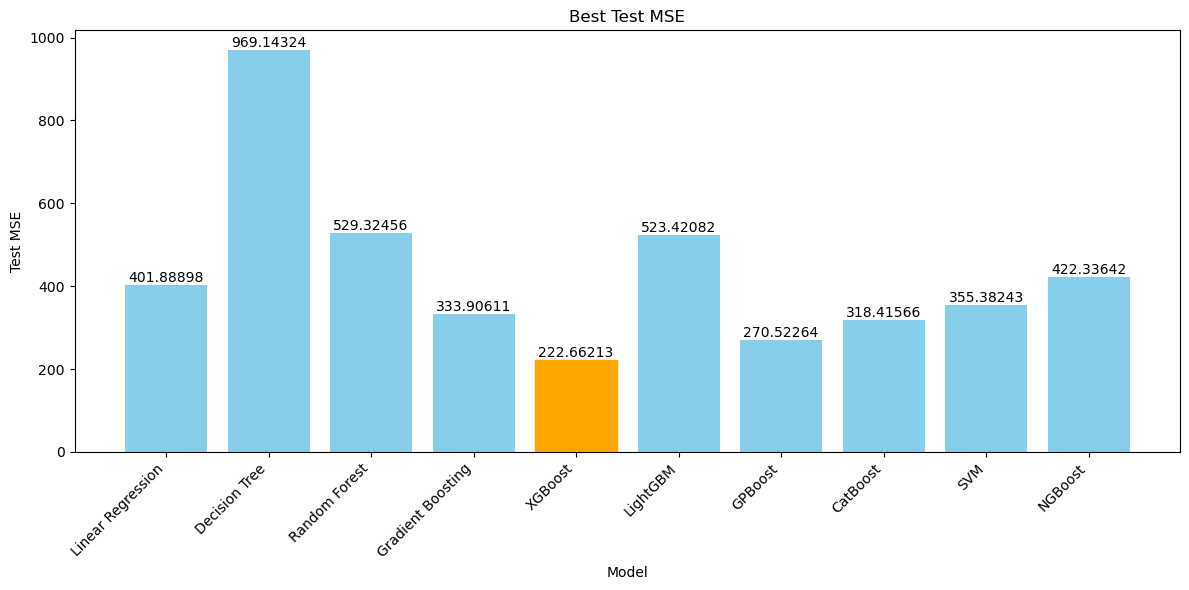

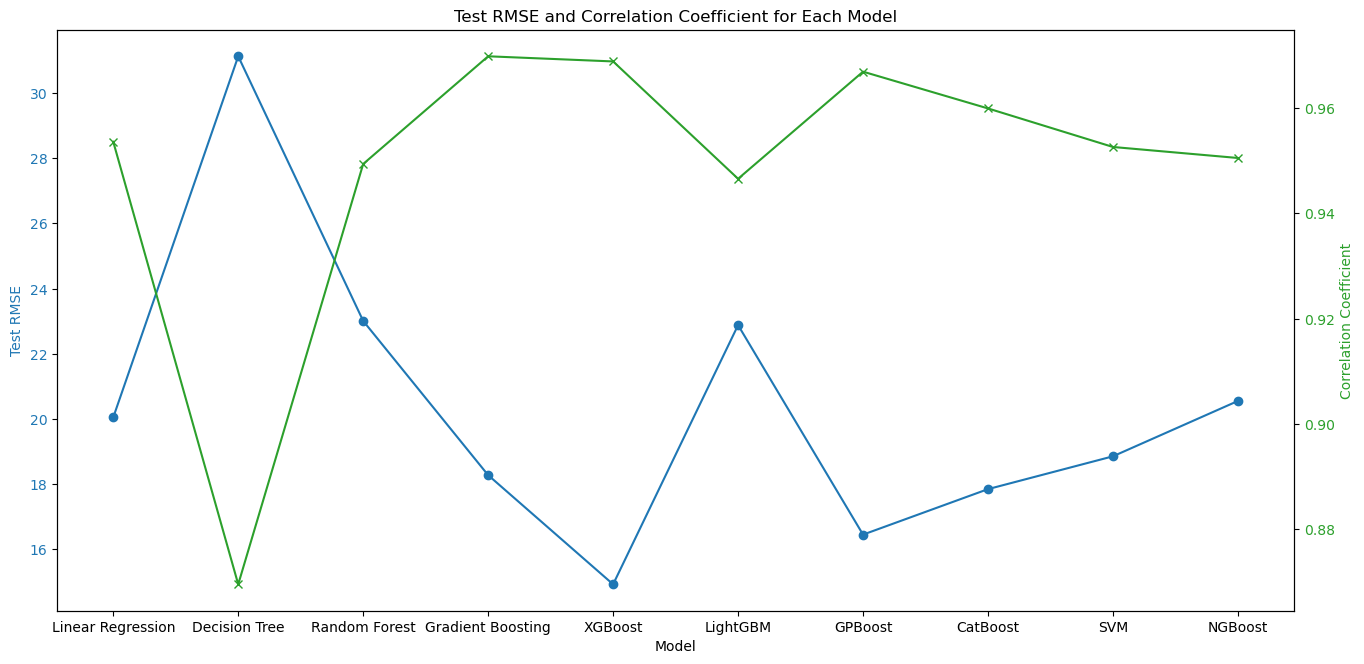

In [91]:
plot_best_scores(best_scores_ran)

# **Grid SearchCV**

In [94]:
def hyperparameter_tuning_grid(X_train, y_train, X_test, y_test):
    models = {
        'Linear Regression': (LinearRegression(), {
            'fit_intercept': [True, False],
            'copy_X': [True, False],
            'n_jobs': [-1, None],
            'positive': [True, False]
        }),
        'Decision Tree': (DecisionTreeRegressor(), {
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }),
        'Random Forest': (RandomForestRegressor(), {
            'n_estimators': [100, 200, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }),
        'Gradient Boosting': (GradientBoostingRegressor(), {
            'n_estimators': [100, 200, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        }),
        'XGBoost': (XGBRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor(verbosity=-1), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'GPBoost': (GPBoostRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0]
        }),
        'CatBoost': (CatBoostRegressor(verbose=0), {
            'learning_rate': [0.01, 0.05, 0.1],
            'iterations': [100, 200, 300, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128]
        }),
        'SVM': (SVR(), {
            'kernel': ['linear', 'rbf', 'poly'],
            'C': [0.1, 1, 10],
            'gamma': [0.01, 0.1, 1],
            'degree': [2, 3, 4],
            'epsilon': [0.01, 0.1, 1]
        }),
        'NGBoost': (NGBRegressor(), {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7]
        })
    }

    best_scores = {}
    for model_name, (model, param_grid) in models.items():
        print(f"Running GridSearchCV for {model_name}...")
        try:
            search = GridSearchCV(model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
            search.fit(X_train, y_train)
            best_model = search.best_estimator_
            y_pred = best_model.predict(X_test)

            # Calculate MSE
            mse = mean_squared_error(y_test, y_pred)

            # Calculate RMSE
            rmse = np.sqrt(mse)

            # Calculate correlation coefficient
            numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
            denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
            corr_coef = numerator / denominator if denominator != 0 else 0.0

            best_scores[model_name] = {
                'best_score': -search.best_score_,
                'best_params': search.best_params_,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }
            print(f"Best MSE for {model_name}: {mse} with params: {search.best_params_}")
            print(f"Best RMSE for {model_name}: {rmse}")
            print(f"Correlation Coefficient for {model_name}: {corr_coef}")
        except Exception as e:
            print(f"Failed to run GridSearchCV for {model_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[best_model_name]
        print(f"\nBest model on test data: {best_model_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_grid = hyperparameter_tuning_grid(X_train, y_train, X_test, y_test)


Running GridSearchCV for Linear Regression...
Best MSE for Linear Regression: 401.8889824197101 with params: {'copy_X': True, 'fit_intercept': True, 'n_jobs': -1, 'positive': True}
Best RMSE for Linear Regression: 20.04716893777548
Correlation Coefficient for Linear Regression: 0.9535369404014369
Running GridSearchCV for Decision Tree...
Best MSE for Decision Tree: 1054.789596761133 with params: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2}
Best RMSE for Decision Tree: 32.477524486344905
Correlation Coefficient for Decision Tree: 0.8605170182806484
Running GridSearchCV for Random Forest...
Best MSE for Random Forest: 620.9931394431362 with params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RMSE for Random Forest: 24.91973393604226
Correlation Coefficient for Random Forest: 0.9470875281057581
Running GridSearchCV for Gradient Boosting...
Best MSE for Gradient Boosting: 291.8

In [95]:
output_file_path =r"C:\Users\dell\Desktop\datascience\projects\results\test_grid.csv"
predict_and_save_results(best_scores_grid, X_train, y_train, X_test, output_file_path)

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.5. Current value: lambda_l2=0.5
[iter 0] loss=5.2670 val_loss=0.0000 scale=2.0000 norm=76.8718
[iter 100] loss=4.4551 val_loss=0.0000 scale=2.0000 norm=27.5146
Predictions have been added to the CSV file.


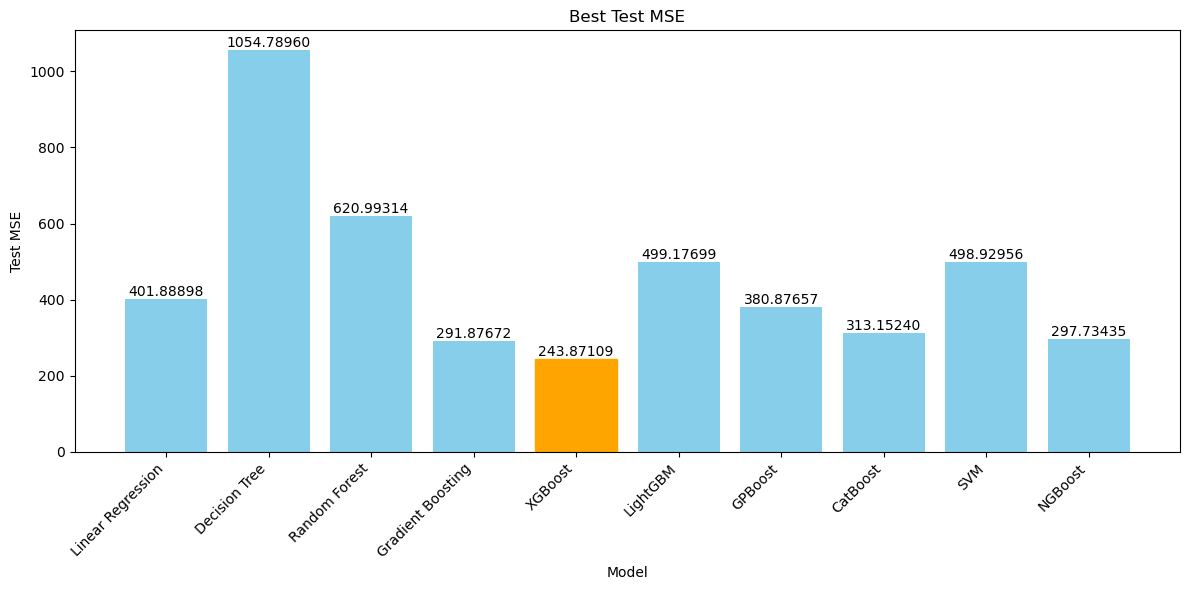

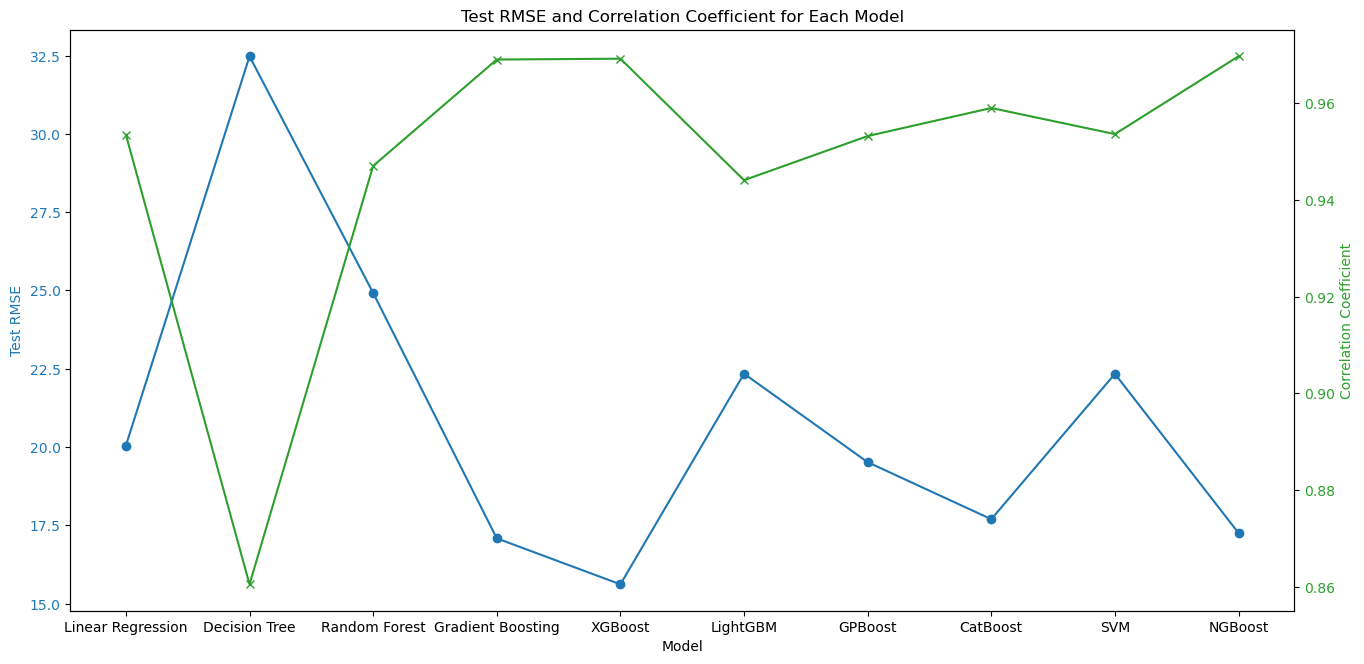

In [96]:
plot_best_scores(best_scores_ran= best_scores_grid)

# **Bayesian Optimization**

In [98]:
def hyperparameter_tuning_bayes_opt(X_train, y_train, X_test, y_test):
    def optimize_model(model, param_bounds, X_train, y_train):
        def objective(**params):
            # Convert parameters to the correct types
            for key in params:
                if key in ['fit_intercept', 'positive']:
                    params[key] = bool(round(params[key]))
                elif key in ['max_depth', 'min_samples_split', 'min_samples_leaf', 'n_estimators', 'iterations', 'num_leaves', 'degree', 'min_child_samples','depth']:
                    params[key] = int(round(params[key]))

            model.set_params(**params)
            # Use cross-validation to evaluate the model
            scores = cross_val_score(model, X_train, y_train, cv=3, scoring=make_scorer(mean_squared_error, greater_is_better=False))
            return np.mean(scores)

        optimizer = BayesianOptimization(f=objective, pbounds=param_bounds, random_state=42, verbose=2)
        optimizer.maximize(init_points=5, n_iter=20)
        return optimizer.max

    models = {
        'Linear Regression': (LinearRegression(), {
            'fit_intercept': (0, 1),
            'positive': (0, 1)
        }),
        'Decision Tree': (DecisionTreeRegressor(), {
            'max_depth': (1, 20),
            'min_samples_split': (2, 11),
            'min_samples_leaf': (1, 5)
        }),
        'Random Forest': (RandomForestRegressor(), {
            'n_estimators': (100, 300),
            'max_depth': (1, 20),
            'min_samples_split': (2, 11),
            'min_samples_leaf': (1, 5)
        }),
        'Gradient Boosting': (GradientBoostingRegressor(), {
            'n_estimators': (100, 500),
            'learning_rate': (0.01, 0.2),
            'max_depth': (1, 20),
            'min_samples_split': (2, 11),
            'min_samples_leaf': (1, 5)
        }),
        'XGBoost': (XGBRegressor(), {
            'learning_rate': (0.01, 0.1),
            'max_depth': (3, 7),
            'n_estimators': (100, 500),
            'min_child_weight': (1, 5),
            'gamma': (0, 1),
            'subsample': (0.5, 0.9),
            'colsample_bytree': (0.5, 0.9)
        }),
        'LightGBM': (LGBMRegressor(verbosity=-1), {
            'learning_rate': (0.01, 0.1),
            'max_depth': (3, 7),
            'n_estimators': (100, 500),
            'num_leaves': (15, 63),
            'min_child_samples': (1, 10),
            'subsample': (0.5, 0.9),
            'colsample_bytree': (0.5, 0.9)
        }),
        'GPBoost': (GPBoostRegressor(), {
            'learning_rate': (0.01, 0.1),
            'max_depth': (3, 7),
            'n_estimators': (100, 500),
            'num_leaves': (15, 63),
            'min_child_samples': (1, 10),
            'subsample': (0.5, 0.9),
            'colsample_bytree': (0.5, 0.9),
            'alpha': (0.1, 1.0),
            'lambda': (0.1, 1.0)
        }),
        'CatBoost': (CatBoostRegressor(verbose=0), {
            'learning_rate': (0.01, 0.1),
            'iterations': (100, 500),
            'depth': (3, 7),
            'l2_leaf_reg': (1, 5)
        }),
        'SVM': (SVR(), {
            'C': (0.1, 10),
            'gamma': (0.01, 1),
            'degree': (2, 4),
            'epsilon': (0.01, 1)
        }),
        'NGBoost': (NGBRegressor(), {
            'n_estimators': (100, 300),
            'learning_rate': (0.01, 0.1),
            'minibatch_frac': (0.5, 1.0)
        })
    }

    best_scores = {}
    for model_name, (model, param_bounds) in models.items():
        print(f"Running Bayesian Optimization for {model_name}...")
        try:
            best_result = optimize_model(model, param_bounds, X_train, y_train)
            best_params = best_result['params']

            # Convert parameters to the correct types for final model fitting
            for key in best_params:
                if key in ['fit_intercept', 'copy_X', 'positive']:
                    best_params[key] = bool(round(best_params[key]))
                elif key in ['max_depth', 'min_samples_split', 'min_samples_leaf', 'n_estimators', 'iterations', 'num_leaves', 'degree', 'min_child_samples', 'depth']:
                    best_params[key] = int(round(best_params[key]))

            model.set_params(**best_params)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Calculate MSE
            mse = mean_squared_error(y_test, y_pred)

            # Calculate RMSE
            rmse = np.sqrt(mse)

            # Calculate correlation coefficient
            numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
            denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
            corr_coef = numerator / denominator if denominator != 0 else 0.0

            best_scores[model_name] = {
                'best_score': -best_result['target'],
                'best_params': best_params,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }
            print(f"Best MSE for {model_name}: {mse} with params: {best_params}")
            print(f"Best RMSE for {model_name}: {rmse}")
            print(f"Correlation Coefficient for {model_name}: {corr_coef}")
        except Exception as e:
            print(f"Failed to run Bayesian Optimization for {model_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[best_model_name]
        print(f"\nBest model on test data: {best_model_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_bayes_opt = hyperparameter_tuning_bayes_opt(X_train, y_train, X_test, y_test)

Running Bayesian Optimization for Linear Regression...
|   iter    |  target   | fit_in... | positive  |
-------------------------------------------------
| 1         | -2.41e+04 | 0.3745    | 0.9507    |
| 2         | -472.2    | 0.732     | 0.5987    |
| 3         | -3.201e+0 | 0.156     | 0.156     |
| 4         | -2.41e+04 | 0.05808   | 0.8662    |
| 5         | -472.2    | 0.6011    | 0.7081    |
| 6         | -472.2    | 0.9098    | 0.8704    |
| 7         | -496.9    | 0.9996    | 0.03361   |
| 8         | -496.9    | 0.9977    | 0.3916    |
| 9         | -472.2    | 0.7187    | 0.6302    |
| 10        | -496.9    | 0.7282    | 0.1711    |
| 11        | -472.2    | 0.9989    | 0.6907    |
| 12        | -472.2    | 0.998     | 0.9979    |
| 13        | -496.9    | 0.7626    | 2.624e-05 |
| 14        | -496.9    | 0.5435    | 0.4848    |
| 15        | -496.9    | 0.8978    | 0.1997    |
| 16        | -496.9    | 0.6041    | 0.1517    |
| 17        | -496.9    | 0.6834    | 0.3708 

In [99]:
output_file_path =r"C:\Users\dell\Desktop\datascience\projects\results\test_bayes.csv"
predict_and_save_results(best_scores_bayes_opt, X_train, y_train, X_test, output_file_path)

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=0.20806286863086093. Current value: lambda_l2=0.20806286863086093
[iter 0] loss=5.5874 val_loss=0.0000 scale=1.0000 norm=45.9638
[iter 100] loss=1.4565 val_loss=0.0000 scale=1.0000 norm=1.0469
[iter 200] loss=-0.2696 val_loss=0.0000 scale=1.0000 norm=0.3313
Predictions have been added to the CSV file.


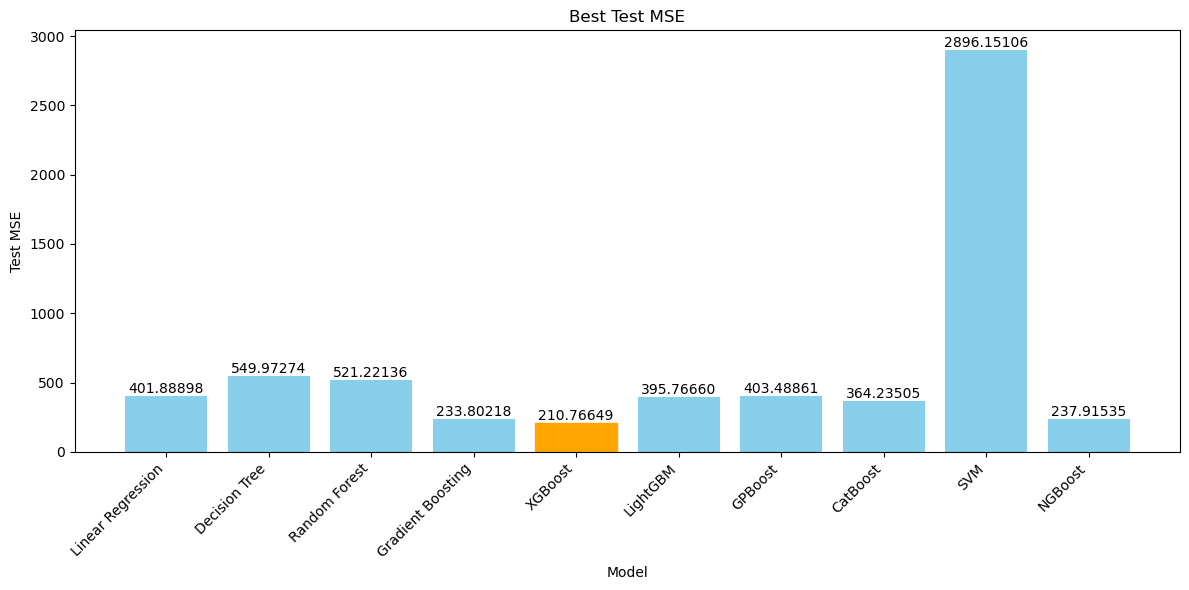

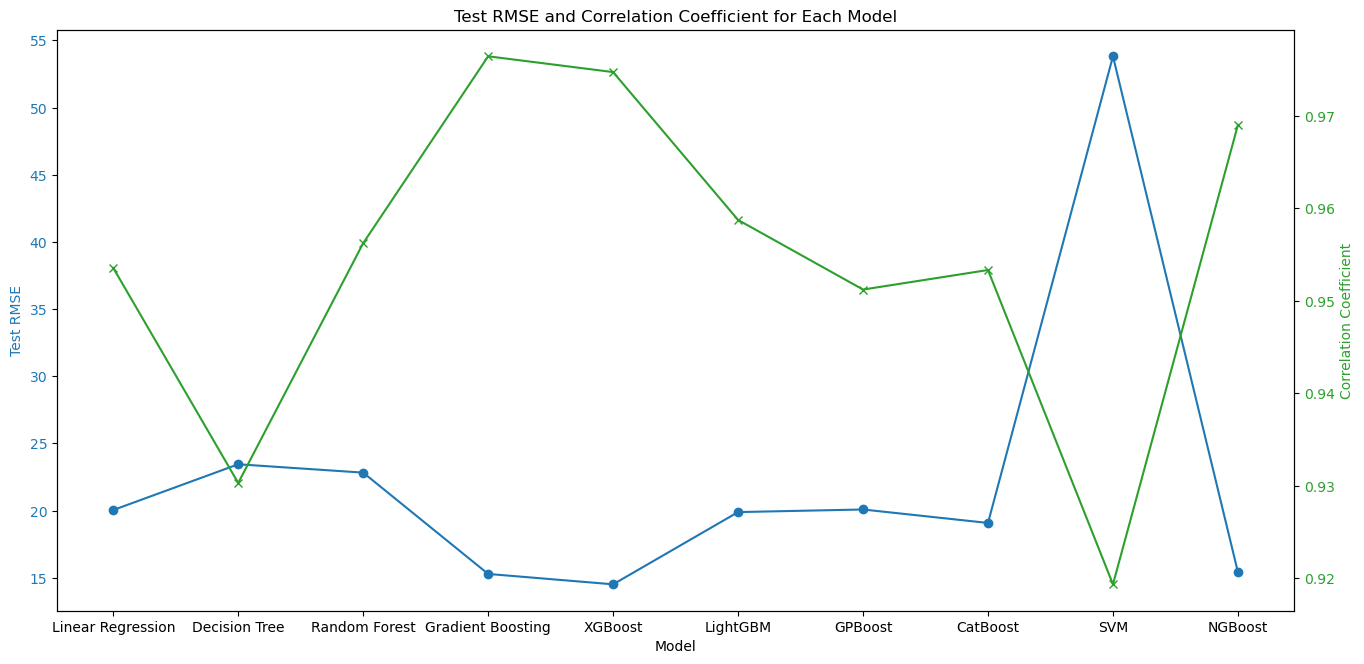

In [100]:
plot_best_scores(best_scores_bayes_opt)

# **Optuna**

In [102]:
# Suppress Optuna's verbose output
optuna.logging.set_verbosity(optuna.logging.WARNING)

def hyperparameter_tuning_optuna(X_train, y_train, X_test, y_test):
    def objective(trial, model_name, model_class, param_space):
        # Suggest hyperparameters
        params = {key: trial.suggest_categorical(key, values) if isinstance(values, list) else trial.suggest_float(key, *values) for key, values in param_space.items()}

        # Create a new instance of the model
        model = model_class()
        model.set_params(**params)

        # Ensure the input arrays are writable
        X_train_copy = np.array(X_train, copy=True)
        y_train_copy = np.array(y_train, copy=True)
        X_test_copy = np.array(X_test, copy=True)
        y_test_copy = np.array(y_test, copy=True)

        # Train model
        model.fit(X_train_copy, y_train_copy)

        # Predict
        y_pred = model.predict(X_test_copy)

        # Calculate MSE
        mse = mean_squared_error(y_test_copy, y_pred)

        return mse

    models = {
        'Linear Regression': (LinearRegression, {
            'fit_intercept': [True, False],
            'copy_X': [True, False],
            'n_jobs': [-1, None],
            'positive': [True, False]
        }),
        'Decision Tree': (DecisionTreeRegressor, {
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }),
        'Random Forest': (RandomForestRegressor, {
            'n_estimators': [100, 200, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }),
        'Gradient Boosting': (GradientBoostingRegressor, {
            'n_estimators': [100, 200, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        }),
        'XGBoost': (XGBRegressor, {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor, {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'GPBoost': (GPBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'alpha': [0.1, 0.5, 1.0],
            'lambda': [0.1, 0.5, 1.0]
        }),
        'CatBoost': (CatBoostRegressor, {
            'learning_rate': [0.01, 0.05, 0.1],
            'iterations': [100, 200, 300, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128]
        }),
        'SVM': (SVR, {
            'kernel': ['linear', 'rbf', 'poly'],
            'C': [0.1, 1, 10],
            'gamma': [0.01, 0.1, 1],
            'degree': [2, 3, 4],
            'epsilon': [0.01, 0.1, 1]
        }),
        'NGBoost': (NGBRegressor, {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7]
        })
    }

    best_scores = {}
    for model_name, (model_class, param_space) in models.items():
        print(f"Running Optuna for {model_name}...")
        try:
            study = optuna.create_study(direction='minimize')
            study.optimize(lambda trial: objective(trial, model_name, model_class, param_space), n_trials=50)

            best_params = study.best_params
            best_model = model_class().set_params(**best_params)
            best_model.fit(X_train, y_train)
            y_pred = best_model.predict(X_test)

            # Calculate MSE
            mse = mean_squared_error(y_test, y_pred)

            # Calculate RMSE
            rmse = np.sqrt(mse)

            # Calculate correlation coefficient
            numerator = np.sum((y_test - np.mean(y_test)) * (y_pred - np.mean(y_pred)))
            denominator = np.sqrt(np.sum((y_test - np.mean(y_test))**2) * np.sum((y_pred - np.mean(y_pred))**2))
            corr_coef = numerator / denominator if denominator != 0 else 0.0

            best_scores[model_name] = {
                'best_score': mse,
                'best_params': best_params,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }
            print(f"Best MSE for {model_name}: {mse} with params: {best_params}")
            print(f"Best RMSE for {model_name}: {rmse}")
            print(f"Correlation Coefficient for {model_name}: {corr_coef}")
        except Exception as e:
            print(f"Failed to run Optuna for {model_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[best_model_name]
        print(f"\nBest model on test data: {best_model_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
    else:
        print("No valid model configurations found.")

    return best_scores

best_scores_optuna = hyperparameter_tuning_optuna(X_train, y_train, X_test, y_test)

[W 2025-04-10 02:01:24,187] Trial 1 failed with parameters: {'fit_intercept': False, 'copy_X': False, 'n_jobs': None, 'positive': True} because of the following error: RuntimeError('Maximum number of iterations reached.').
Traceback (most recent call last):
  File "C:\Users\dell\anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\dell\AppData\Local\Temp\ipykernel_14092\3467623998.py", line 114, in <lambda>
    study.optimize(lambda trial: objective(trial, model_name, model_class, param_space), n_trials=50)
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\dell\AppData\Local\Temp\ipykernel_14092\3467623998.py", line 20, in objective
    model.fit(X_train_copy, y_train_copy)
  File "C:\Users\dell\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
          

Running Optuna for Linear Regression...
Failed to run Optuna for Linear Regression. Error: Maximum number of iterations reached.
Running Optuna for Decision Tree...
Best MSE for Decision Tree: 458.1487590573285 with params: {'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None}
Best RMSE for Decision Tree: 21.404409803994326
Correlation Coefficient for Decision Tree: 0.9463096638629716
Running Optuna for Random Forest...
Best MSE for Random Forest: 523.4480826778006 with params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None}
Best RMSE for Random Forest: 22.878987798366442
Correlation Coefficient for Random Forest: 0.951611164194459
Running Optuna for Gradient Boosting...
Best MSE for Gradient Boosting: 309.30161839776235 with params: {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best RMSE for Gradient Boost

In [103]:
output_file_path =r"C:\Users\dell\Desktop\datascience\projects\results\test_optuna.csv"
predict_and_save_results(best_scores_optuna, X_train, y_train, X_test, output_file_path)

[GPBoost] [Warning] lambda_l2 is set with reg_lambda=0.0, will be overridden by lambda=1.0. Current value: lambda_l2=1.0
[iter 0] loss=5.2895 val_loss=0.0000 scale=1.0000 norm=39.3071
[iter 100] loss=4.3717 val_loss=0.0000 scale=2.0000 norm=24.6403
Predictions have been added to the CSV file.


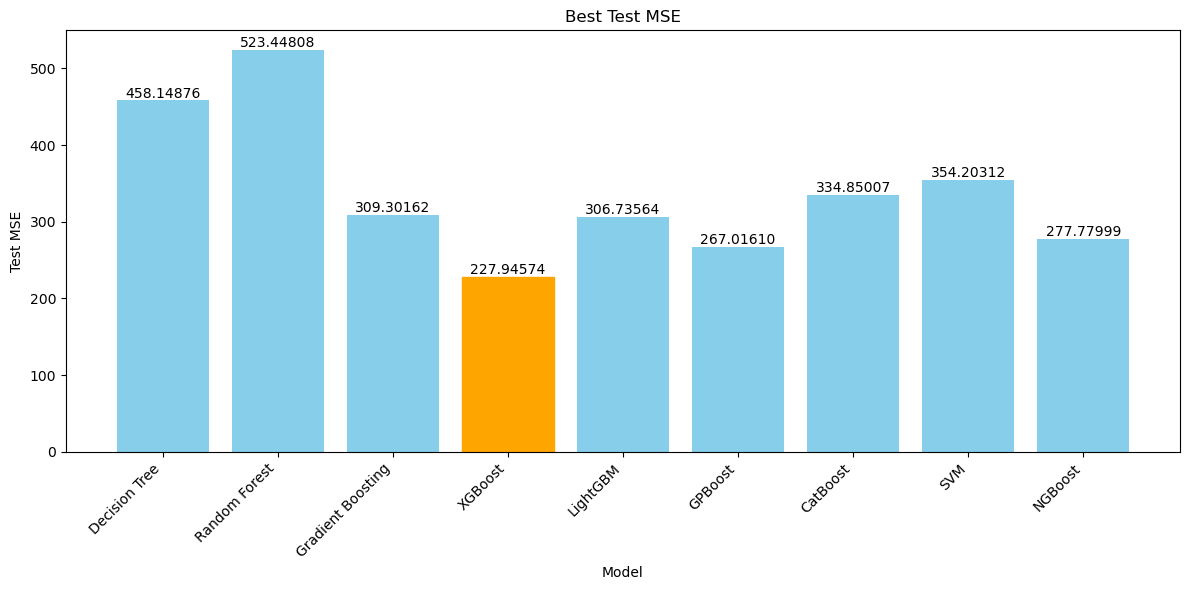

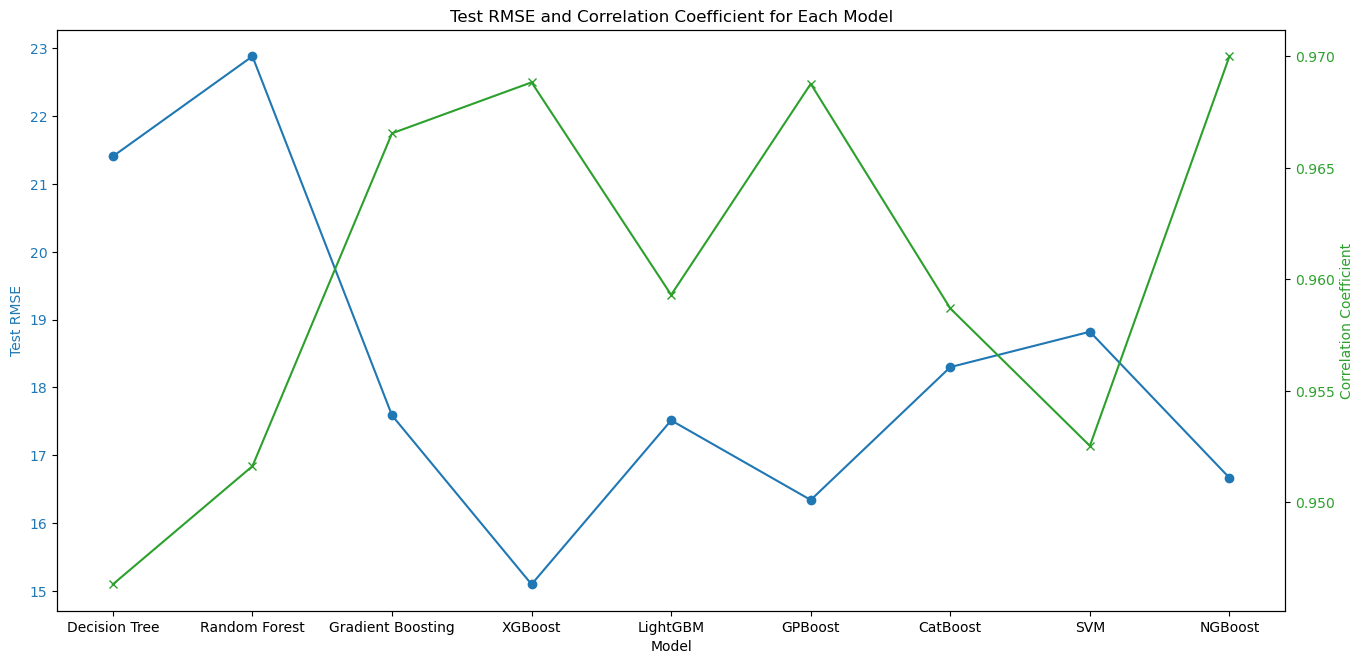

In [104]:
plot_best_scores(best_scores_ran= best_scores_optuna)

# **Hyper Opt**

In [106]:
def hyperparameter_tuning_hyperopt(X_train, y_train, X_test, y_test):
    def create_objective(model_class, param_space):
        def objective(params):
            try:
                model = model_class(**params)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                mse = mean_squared_error(y_test, y_pred)
                return {'loss': mse, 'status': STATUS_OK, 'params': params}
            except Exception as e:
                print(f"Error in model fitting: {e}")
                return {'loss': float('inf'), 'status': STATUS_OK}
        return objective

    # Define model configurations
    model_configs = {
        'Linear Regression': (LinearRegression, {
            'fit_intercept': hp.choice('fit_intercept', [True, False]),
            'positive': hp.choice('positive', [True, False])
        }),
        'Decision Tree': (DecisionTreeRegressor, {
            'max_depth': hp.choice('dt_max_depth', [None, 5, 10, 15]),
            'min_samples_split': hp.choice('dt_min_samples_split', [2, 5, 10]),
            'min_samples_leaf': hp.choice('dt_min_samples_leaf', [1, 2, 4]),
            'max_features': hp.choice('dt_max_features', ['sqrt', 'log2', None]),
            'random_state': 42
        }),
        'Random Forest': (RandomForestRegressor, {
            'n_estimators': hp.choice('rf_n_estimators', [100, 200, 500]),
            'max_depth': hp.choice('rf_max_depth', [None, 5, 10, 15]),
            'min_samples_split': hp.choice('rf_min_samples_split', [2, 5, 10]),
            'min_samples_leaf': hp.choice('rf_min_samples_leaf', [1, 2, 4]),
            'max_features': hp.choice('rf_max_features', ['sqrt', 'log2', None]),
            'random_state': 42
        }),
        'Gradient Boosting': (GradientBoostingRegressor, {
            'n_estimators': hp.choice('gb_n_estimators', [100, 200, 500]),
            'learning_rate': hp.choice('gb_learning_rate', [0.01, 0.05, 0.1]),
            'max_depth': hp.choice('gb_max_depth', [3, 5, 10]),
            'min_samples_split': hp.choice('gb_min_samples_split', [2, 5, 10]),
            'min_samples_leaf': hp.choice('gb_min_samples_leaf', [1, 2, 4]),
            'max_features': hp.choice('gb_max_features', ['sqrt', 'log2']),
            'random_state': 42
        }),
        'XGBoost': (XGBRegressor, {
            'learning_rate': hp.choice('xgb_learning_rate', [0.01, 0.05, 0.1]),
            'max_depth': hp.choice('xgb_max_depth', [3, 5, 7]),
            'n_estimators': hp.choice('xgb_n_estimators', [100, 200, 300, 500]),
            'min_child_weight': hp.choice('xgb_min_child_weight', [1, 3, 5]),
            'gamma': hp.choice('xgb_gamma', [0, 0.1, 0.5, 1]),
            'subsample': hp.choice('xgb_subsample', [0.5, 0.7, 0.9]),
            'colsample_bytree': hp.choice('xgb_colsample_bytree', [0.5, 0.7, 0.9]),
            'random_state': 42
        }),
        'LightGBM': (LGBMRegressor, {
            'learning_rate': hp.choice('lgbm_learning_rate', [0.01, 0.05, 0.1]),
            'max_depth': hp.choice('lgbm_max_depth', [3, 5, 7]),
            'n_estimators': hp.choice('lgbm_n_estimators', [100, 200, 300, 500]),
            'num_leaves': hp.choice('lgbm_num_leaves', [15, 31, 63]),
            'min_child_samples': hp.choice('lgbm_min_child_samples', [1, 5, 10]),
            'subsample': hp.choice('lgbm_subsample', [0.5, 0.7, 0.9]),
            'colsample_bytree': hp.choice('lgbm_colsample_bytree', [0.5, 0.7, 0.9]),
            'random_state': 42,
            'verbose': -1
        }),
        'GPBoost': (GPBoostRegressor, {
            'learning_rate': hp.choice('gpboost_learning_rate', [0.01, 0.05, 0.1]),
            'max_depth': hp.choice('gpboost_max_depth', [3, 5, 7]),
            'n_estimators': hp.choice('gpboost_n_estimators', [100, 200, 300, 500]),
            'num_leaves': hp.choice('gpboost_num_leaves', [15, 31, 63]),
            'min_data_in_leaf': hp.choice('gpboost_min_data_in_leaf', [1, 5, 10]),
            'subsample': hp.choice('gpboost_subsample', [0.5, 0.7, 0.9]),
            'colsample_bytree': hp.choice('gpboost_colsample_bytree', [0.5, 0.7, 0.9]),
            'lambda_l2': hp.choice('gpboost_lambda_l2', [0.1, 0.5, 1.0]),
            'random_state': 42,
            'verbose': -1
        }),
        'CatBoost': (CatBoostRegressor, {
            'learning_rate': hp.choice('catboost_learning_rate', [0.01, 0.05, 0.1]),
            'iterations': hp.choice('catboost_iterations', [100, 200, 300, 500]),
            'depth': hp.choice('catboost_depth', [3, 5, 7]),
            'l2_leaf_reg': hp.choice('catboost_l2_leaf_reg', [1, 3, 5]),
            'border_count': hp.choice('catboost_border_count', [32, 64, 128]),
            'random_state': 42
        }),
        'SVM': (SVR, {
            'kernel': hp.choice('svm_kernel', ['linear', 'rbf', 'poly']),
            'C': hp.loguniform('svm_C', np.log(0.1), np.log(10)),
            'gamma': hp.choice('svm_gamma', ['scale', 'auto']),
            'degree': hp.choice('svm_degree', [2, 3, 4]),
            'epsilon': hp.choice('svm_epsilon', [0.01, 0.1, 1])
        }),
        'NGBoost': (NGBRegressor, {
            'n_estimators': hp.choice('ngb_n_estimators', [100, 200]),
            'learning_rate': hp.choice('ngb_learning_rate', [0.01, 0.1]),
            'natural_gradient': hp.choice('ngb_natural_gradient', [True, False]),
            'minibatch_frac': hp.choice('ngb_minibatch_frac', [0.5, 0.7]),
            'verbose': 0,
            'random_state': 42
        })
    }

    best_scores = {}

    for model_name, (model_class, param_space) in model_configs.items():
        print(f"\nOptimizing {model_name}...")
        try:
            # Create new trials for each model
            model_trials = Trials()

            # Run optimization for this model
            best = fmin(
                fn=create_objective(model_class, param_space),
                space=param_space,
                algo=tpe.suggest,
                max_evals=50,
                trials=model_trials,
                show_progressbar=False
            )

            # Use space_eval to get best parameters
            best_params = space_eval(param_space, best)

            # Create and train best model
            best_model = model_class(**best_params)
            best_model.fit(X_train, y_train)
            y_pred = best_model.predict(X_test)

            # Calculate metrics
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            corr_coef = np.corrcoef(y_test, y_pred)[0, 1]

            best_scores[model_name] = {
                'best_score': mse,
                'best_params': best_params,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }

            print(f"{model_name}:")
            print(f"Best Parameters: {best_params}")
            print(f"MSE: {mse:.6f}")
            print(f"RMSE: {rmse:.6f}")
            print(f"Correlation Coefficient: {corr_coef:.6f}")

        except Exception as e:
            print(f"Error optimizing {model_name}: {str(e)}")
            continue

    # Find the best overall model
    if best_scores:
        best_model_name = min(best_scores.keys(), key=lambda k: best_scores[k]['test_mse'])
        print(f"\nBest Overall Model: {best_model_name}")
        print(f"Best Overall MSE: {best_scores[best_model_name]['test_mse']:.6f}")
        print(f"Best Overall RMSE: {best_scores[best_model_name]['test_rmse']:.6f}")
        print(f"Best Overall Correlation Coefficient: {best_scores[best_model_name]['test_corr_coef']:.6f}")

    return best_scores

best_scores_hyperopt = hyperparameter_tuning_hyperopt(X_train, y_train, X_test, y_test)


Optimizing Linear Regression...
Error in model fitting: Maximum number of iterations reached.
Error in model fitting: Maximum number of iterations reached.
Error in model fitting: Maximum number of iterations reached.
Error in model fitting: Maximum number of iterations reached.
Error in model fitting: Maximum number of iterations reached.
Error in model fitting: Maximum number of iterations reached.
Error in model fitting: Maximum number of iterations reached.
Error in model fitting: Maximum number of iterations reached.
Error in model fitting: Maximum number of iterations reached.
Linear Regression:
Best Parameters: {'fit_intercept': True, 'positive': True}
MSE: 401.888982
RMSE: 20.047169
Correlation Coefficient: 0.953537

Optimizing Decision Tree...
Decision Tree:
Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'random_state': 42}
MSE: 499.719282
RMSE: 22.354402
Correlation Coefficient: 0.935685

Optimizing Random Forest...
Ra

In [107]:
output_file_path =r"C:\Users\dell\Desktop\datascience\projects\results\test_hyperopt.csv"
predict_and_save_results(best_scores_hyperopt, X_train, y_train, X_test, output_file_path)

[GPBoost] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[GPBoost] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5
Predictions have been added to the CSV file.


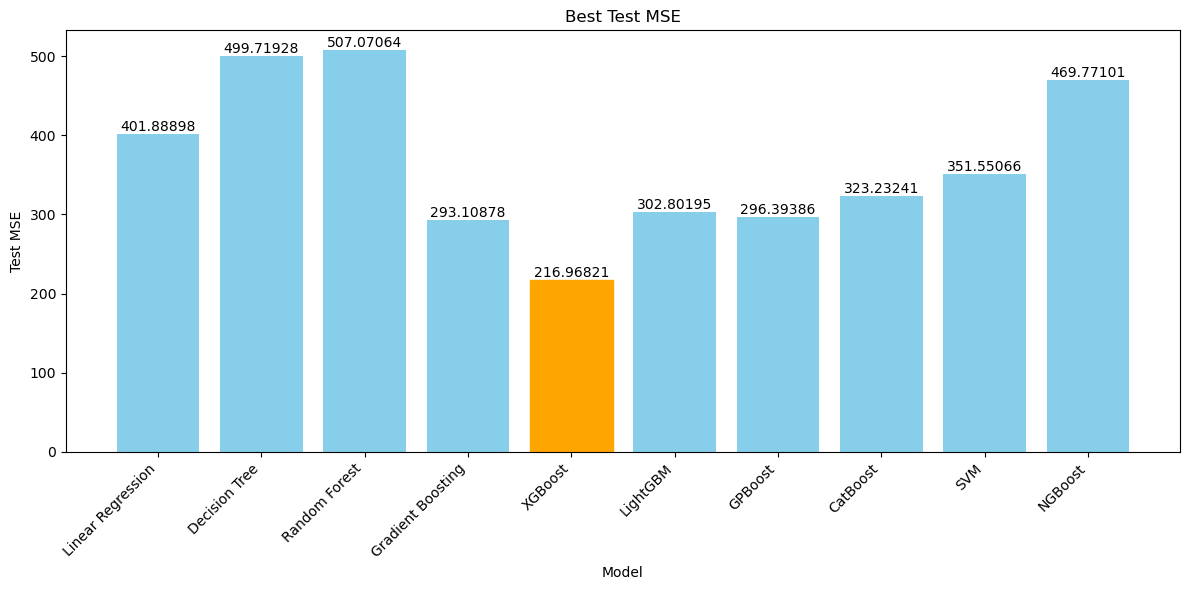

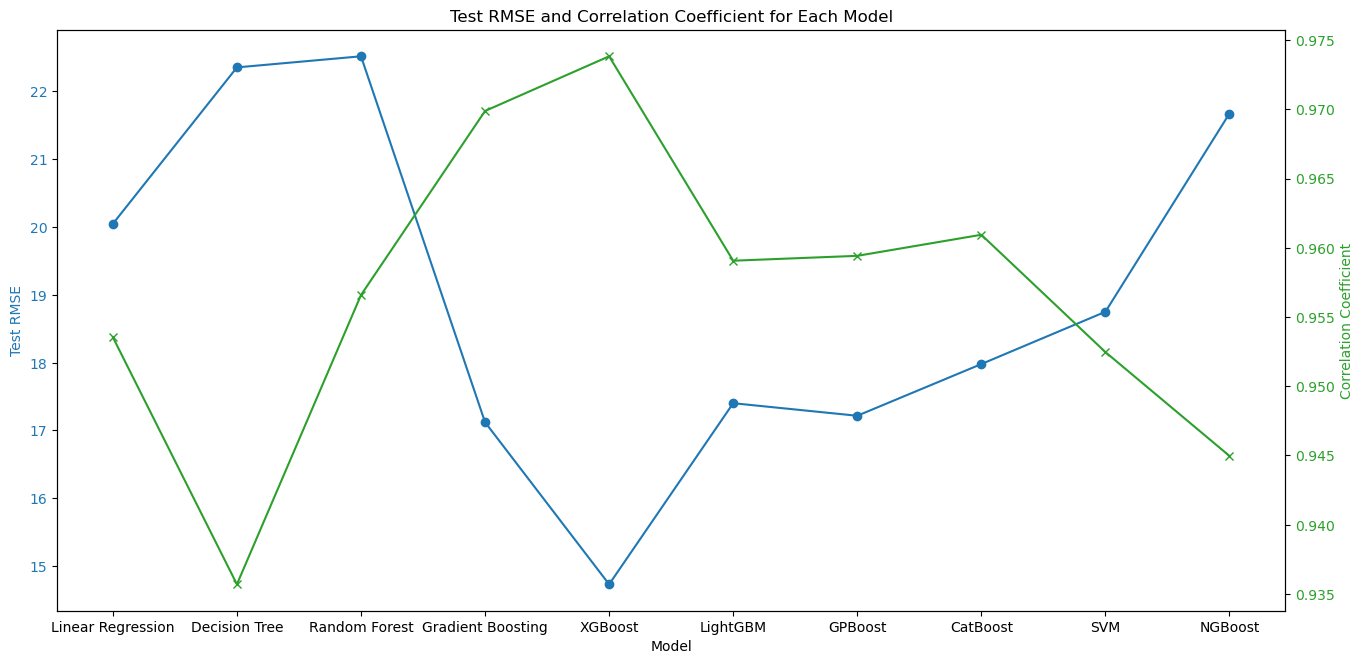

In [108]:
plot_best_scores(best_scores_ran= best_scores_hyperopt)

# **Halving GridSearchCV**

In [110]:
def hyperparameter_tuning_halving_grid(X_train, y_train, X_test, y_test):
    models = {
        'Linear Regression': (LinearRegression(), {
            'fit_intercept': [True, False],
            'positive': [True, False]
        }),
        'Decision Tree': (DecisionTreeRegressor(), {
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }),
        'Random Forest': (RandomForestRegressor(), {
            'n_estimators': [100, 200, 500],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None]
        }),
        'Gradient Boosting': (GradientBoostingRegressor(), {
            'n_estimators': [100, 200, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        }),
        'XGBoost': (XGBRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.5, 1],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'LightGBM': (LGBMRegressor(verbosity=-1), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [1, 5, 10],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9]
        }),
        'GPBoost': (GPBoostRegressor(), {
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'n_estimators': [100, 200, 300, 500],
            'num_leaves': [15, 31, 63],
            'min_data_in_leaf': [1, 5, 10],
            'subsample': [0.5, 0.7, 0.9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'lambda_l1': [0.0, 0.1, 0.5],
            'lambda_l2': [0.0, 0.1, 0.5]
        }),
        'CatBoost': (CatBoostRegressor(verbose=0), {
            'learning_rate': [0.01, 0.05, 0.1],
            'iterations': [100, 200, 300, 500],
            'depth': [3, 5, 7],
            'l2_leaf_reg': [1, 3, 5],
            'border_count': [32, 64, 128]
        }),
        'SVM': (SVR(), {
            'kernel': ['linear', 'rbf', 'poly'],
            'C': [0.1, 1, 10],
            'gamma': ['scale', 'auto', 0.01, 0.1, 1],
            'degree': [2, 3, 4],
            'epsilon': [0.01, 0.1, 1]
        }),
        'NGBoost': (NGBRegressor(verbose=0), {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'natural_gradient': [True, False],
            'minibatch_frac': [0.5, 0.7]
        })
    }

    best_scores = {}
    for model_name, (model, param_grid) in models.items():
        print(f"Running HalvingGridSearchCV for {model_name}...")
        try:
            search = HalvingGridSearchCV(
                estimator=model,
                param_grid=param_grid,
                cv=3,
                factor=2,  # Reduction factor at each iteration
                scoring='neg_mean_squared_error',
                n_jobs=-1,
                verbose=0
            )

            search.fit(X_train, y_train)
            best_model = search.best_estimator_
            y_pred = best_model.predict(X_test)

            # Calculate MSE
            mse = mean_squared_error(y_test, y_pred)

            # Calculate RMSE
            rmse = np.sqrt(mse)

            # Calculate correlation coefficient
            corr_coef = np.corrcoef(y_test, y_pred)[0, 1]

            best_scores[model_name] = {
                'best_score': -search.best_score_,
                'best_params': search.best_params_,
                'test_mse': mse,
                'test_rmse': rmse,
                'test_corr_coef': corr_coef
            }
            print(f"Best MSE for {model_name}: {mse} with params: {search.best_params_}")
            print(f"Best RMSE for {model_name}: {rmse}")
            print(f"Correlation Coefficient for {model_name}: {corr_coef}")
        except Exception as e:
            print(f"Failed to run HalvingGridSearchCV for {model_name}. Error: {e}")

    # Find the model with the best test score
    if best_scores:
        best_model_name = min(best_scores, key=lambda k: best_scores[k]['test_mse'])
        best_model_info = best_scores[best_model_name]
        print(f"\nBest model on test data: {best_model_name}")
        print(f"Test MSE: {best_model_info['test_mse']}")
        print(f"Test RMSE: {best_model_info['test_rmse']}")
        print(f"Correlation Coefficient: {best_model_info['test_corr_coef']}")
        print(f"Best Parameters: {best_model_info['best_params']}")
    else:
        print("No valid model configurations found.")

    return best_scores

# Example usage
best_scores_halving_grid = hyperparameter_tuning_halving_grid(X_train, y_train, X_test, y_test)

# Removing Warnings
warnings.filterwarnings('ignore', message='.*lambda_l2 is set with lambda.*')
warnings.filterwarnings('ignore', message='.*min_data_in_leaf is set.*')

Running HalvingGridSearchCV for Linear Regression...
Best MSE for Linear Regression: 426.28881593363514 with params: {'fit_intercept': True, 'positive': False}
Best RMSE for Linear Regression: 20.64676284393355
Correlation Coefficient for Linear Regression: 0.9491830657370945
Running HalvingGridSearchCV for Decision Tree...
Best MSE for Decision Tree: 505.6455400187154 with params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5}
Best RMSE for Decision Tree: 22.486563544008128
Correlation Coefficient for Decision Tree: 0.9359141998294439
Running HalvingGridSearchCV for Random Forest...
Best MSE for Random Forest: 479.899998427817 with params: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RMSE for Random Forest: 21.90661996812418
Correlation Coefficient for Random Forest: 0.959488638993434
Running HalvingGridSearchCV for Gradient Boosting...
Best MSE for Gradient Boosting: 416.07570

In [111]:
output_file_path =r"C:\Users\dell\Desktop\datascience\projects\results\test_halving_grid.csv"
predict_and_save_results(best_scores_halving_grid, X_train, y_train, X_test, output_file_path)

[GPBoost] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[GPBoost] [Warning] lambda_l1 is set=0.5, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.5
[GPBoost] [Warning] lambda_l2 is set=0.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0
[iter 0] loss=5.5484 val_loss=0.0000 scale=1.0000 norm=47.2081
Predictions have been added to the CSV file.


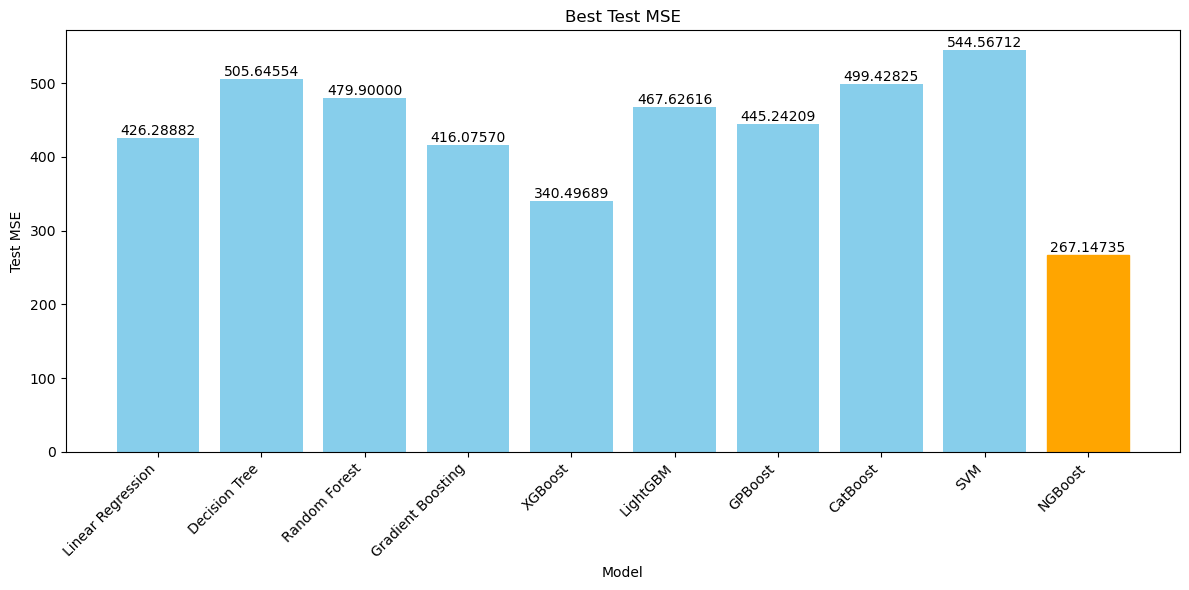

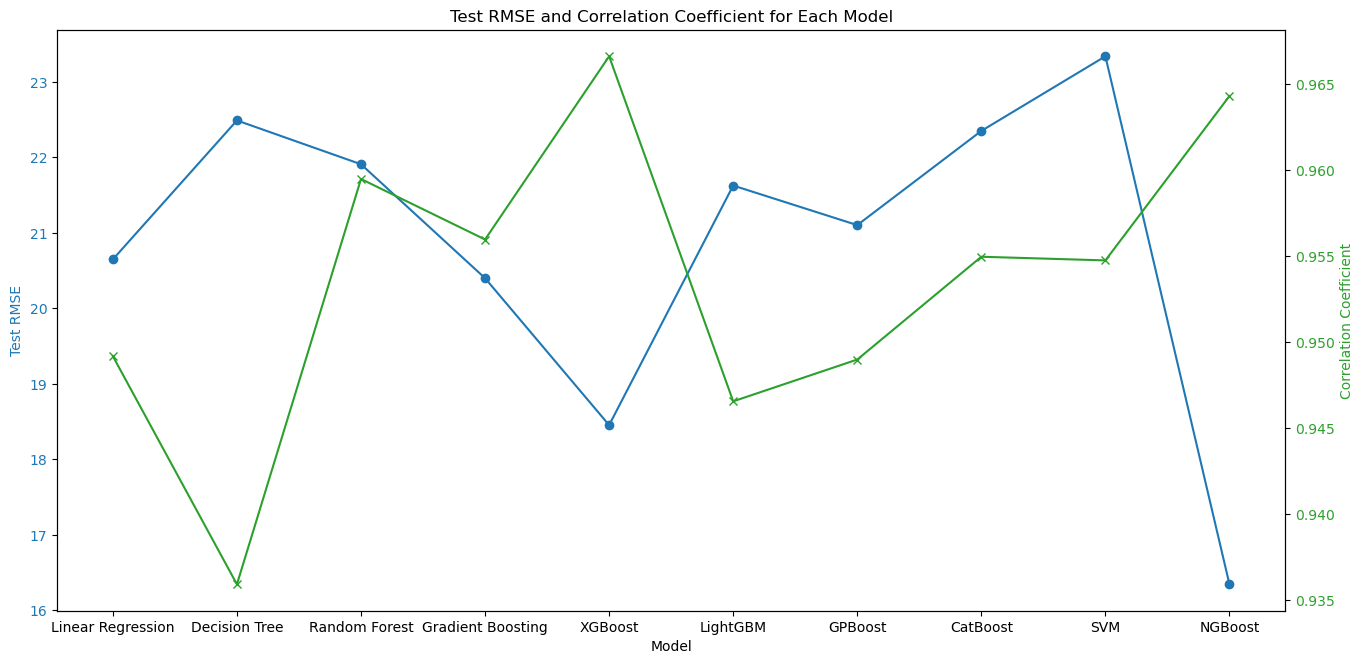

In [112]:
plot_best_scores(best_scores_ran= best_scores_halving_grid)

# **HyperBand**

In [28]:
def build_model(hp, model_type):
    model = keras.Sequential()
    input_shape = (X_train.shape[1],)

    activation_functions = [
         'tanh',
         'elu', 'selu',
        'softplus', 'softsign', 'hard_sigmoid'
    ]
    activation = activation_functions[model_type - 1]

    # Add a single dense layer with variable units and the chosen activation function
    model.add(keras.layers.Dense(
        units=hp.Int('units', min_value=32, max_value=512, step=32),
        activation=activation,
        input_shape=input_shape
    ))
    model.add(keras.layers.Dense(1))  # Output layer for regression

    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        ),
        loss='mse',
        metrics=['mse']
    )
    return model

# Create a dictionary of model types
model_types = {f'Model {i}': i for i in range(1, 7)}

# Function to tune and evaluate each model
def tune_and_evaluate(model_type, model_name):
    def model_builder(hp):
        return build_model(hp, model_type)

    tuner = Hyperband(
        model_builder,
        objective='val_mse',
        max_epochs=30,
        factor=3,
        directory='my_dir',
        project_name=f'intro_to_kt_{model_name}'
    )

    # Run the hyperparameter search
    tuner.search(X_train, y_train, epochs=50, validation_split=0.2, verbose=1)

    # Get the optimal hyperparameters
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

    # Build the model with the optimal hyperparameters and train it
    model = tuner.hypermodel.build(best_hps)
    model.fit(X_train, y_train, epochs=1, validation_split=0.2)

    # Evaluate the model
    y_pred = model.predict(X_test).flatten()  # Flatten the predictions
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    corr_coef = np.corrcoef(y_test, y_pred)[0, 1]

    print(f"{model_name} - Test MSE: {mse}")
    print(f"{model_name} - Test RMSE: {rmse}")
    print(f"{model_name} - Correlation Coefficient: {corr_coef}")

    return {
        'test_mse': mse,
        'test_rmse': rmse,
        'test_corr_coef': corr_coef,
        'best_parameters': best_hps.values
    }

# Tune and evaluate each model
results = {}
for model_name, model_type in model_types.items():
    results[model_name] = tune_and_evaluate(model_type, model_name)

# Compare results
best_model_name = min(results, key=lambda k: results[k]['test_mse'])  # Compare based on MSE
print(f"\nBest model: {best_model_name} with MSE: {results[best_model_name]['test_mse']}")
print(f"Best RMSE: {results[best_model_name]['test_rmse']}")
print(f"Best Correlation Coefficient: {results[best_model_name]['test_corr_coef']}")
print(f"Best hyperparameters: {results[best_model_name]['best_parameters']}")

Trial 65 Complete [00h 00m 04s]
val_mse: 13877.703125

Best val_mse So Far: 1173.9114990234375
Total elapsed time: 00h 04m 06s
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step - loss: 21061.6562 - mse: 21061.6562 - val_loss: 12732.8262 - val_mse: 12732.8262
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Model 6 - Test MSE: 22778.669306478507
Model 6 - Test RMSE: 150.92603919297196
Model 6 - Correlation Coefficient: 0.8168857115002648

Best model: Model 4 with MSE: 21624.537962437815
Best RMSE: 147.05284071529462
Best Correlation Coefficient: 0.7671270283192574
Best hyperparameters: {'units': 512, 'learning_rate': 0.01, 'tuner/epochs': 30, 'tuner/initial_epoch': 10, 'tuner/bracket': 3, 'tuner/round': 3, 'tuner/trial_id': '0046'}


In [41]:
import pandas as pd
import numpy as np
from keras_tuner.engine.hyperparameters import HyperParameters
import os

# Function to predict and save results for Keras models
def predict_and_save_results(results, X_train, y_train, X_test, output_file_path):
    # Check if the file exists
    if os.path.exists(output_file_path):
        # Load the existing Excel file
        predictions_df = pd.read_excel(output_file_path)
    else:
        # Create a new DataFrame if the file does not exist
        predictions_df = pd.DataFrame()

    for model_name, model_info in results.items():
        best_params_dict = model_info['best_parameters']

        # Extract model_type from model_name (assuming 'Model 1', 'Model 2', etc.)
        model_type = int(model_name.split()[1])

        # Recreate the HyperParameters object and set the best hyperparameters
        hp = HyperParameters()
        for param_name, param_value in best_params_dict.items():
            if not param_name.startswith('tuner/'):  # Exclude 'tuner/' entries
                hp.Fixed(param_name, param_value)

        # Build the model with the best hyperparameters
        model = build_model(hp, model_type)

        # Retrieve the number of epochs used during tuning
        epochs = best_params_dict.get('tuner/epochs', 50)  # Default to 50 if not found

        # Train the model on the full training data
        model.fit(X_train, y_train, epochs=epochs, validation_split=0.2, verbose=0)

        # Make predictions on the test data
        y_pred = model.predict(X_test).flatten()

        # Add predictions to the DataFrame
        predictions_df[f'Sd_{model_name}'] = np.round(y_pred, 2)

    # Save the predictions to an Excel file at the specified location
    predictions_df.to_excel(output_file_path, index=False)
    print("Predictions have been added to the Excel file.")

# Example usage
output_file_path = r"C:\Users\dell\Desktop\datascience\projects\results\test_hyperband.xlsx"
predict_and_save_results(results, X_train, y_train, X_test, output_file_path)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predictions have been added to the Excel file.


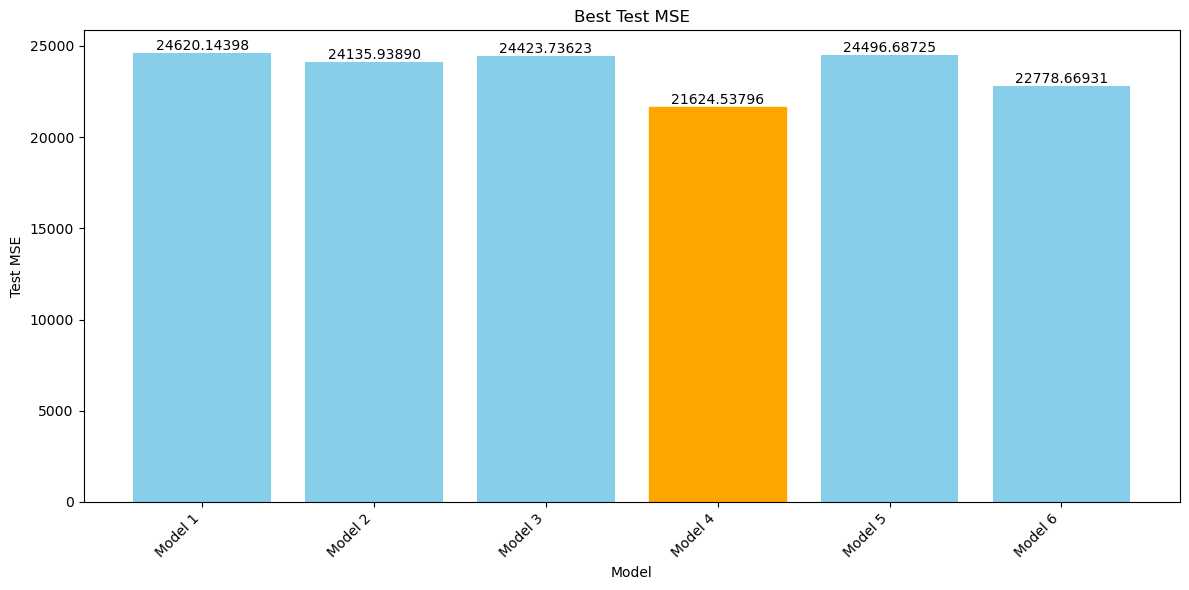

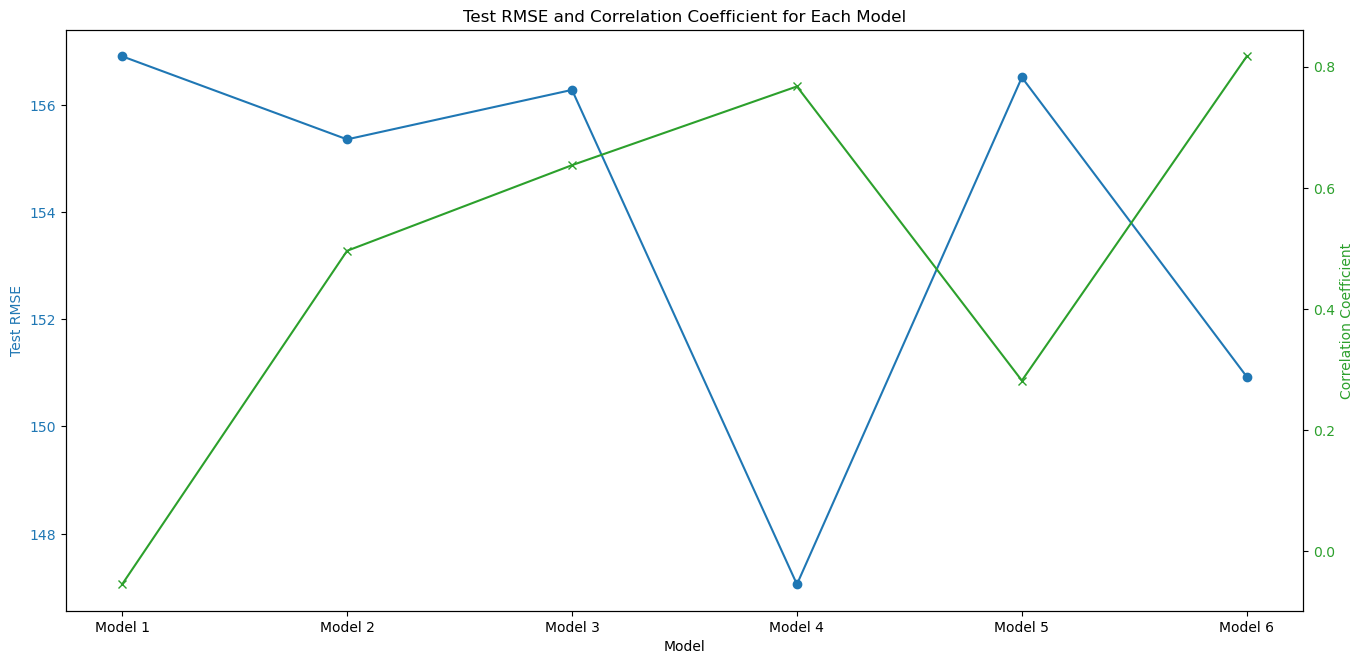

In [42]:
plot_best_scores(best_scores_ran= results)